## Variational Bayes for Normal Model

This notebook demonstrates how to apply Mean-Field Variational Bayes (MFVB) for Bayesian estimation in a normal model. The implementation follows the practical tutorial by Tran, Nguyen and Dao (2021), whose original MATLAB code has been translated to Python.

### Step 1: Define MFVB alogrithm based on normal prior assumtion 

In [5]:
"""
Mean-Field Variational Bayes (MFVB) for the Normal model
Reference: "A practical tutorial on Variational Bayes" by Minh-Ngoc Tran

Python translation of the original MATLAB script.
Structure:
    1. Helper functions (Gibbs sampler + MFVB optimiser)
    2. Synthetic data
    3. Execution + visualisation (MCMC vs VB posterior densities)
"""
import time
import numpy as np
from scipy.stats import gaussian_kde, norm, invgamma
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------------------
def gibbs_normal_model(y, alpha0, beta0, mu0, sigma20,
                        Nburn=10000, Niter=20000, seed=2020):
    """
    Gibbs sampler for the normal model:
        y_i | mu, sigma2 ~ N(mu, sigma2)
        mu               ~ N(mu0, sigma20)
        sigma2           ~ InvGamma(alpha0, beta0)

    Returns
    -------
    mu_mcmc, sigma2_mcmc : ndarray
        Post burn-in MCMC draws.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    n = len(y)
    y_bar = y.mean()

    N = Nburn + Niter
    mu_mcmc = np.zeros(N)
    sigma2_mcmc = np.zeros(N)

    # initial values sample mean and sample variance
    mu_mcmc[0] = y_bar
    sigma2_mcmc[0] = y.var(ddof=1)

    for i in range(N - 1):
        # full conditional for mu
        scale = 1.0 / (1.0 / sigma20 + n / sigma2_mcmc[i])
        location = n * y_bar / sigma2_mcmc[i] * scale
        mu_mcmc[i + 1] = rng.normal(location, np.sqrt(scale))

        # full conditional for sigma2 (via precision ~ Gamma)
        shape = n / 2 + alpha0
        rate = beta0 + np.sum((y - mu_mcmc[i + 1]) ** 2) / 2
        # numpy's gamma(shape, scale) uses scale = 1/rate
        # Random Gamma: gamrnd(shape, 1/rate)
        precision = rng.gamma(shape, 1.0 / rate)
        sigma2_mcmc[i + 1] = 1.0 / precision

    return mu_mcmc[Nburn:], sigma2_mcmc[Nburn:]


def mfvb_normal_model(y, alpha0, beta0, mu0, sigma20,
                       eps=1e-4, max_iter=10000):
    """
    Mean-field variational Bayes for the normal model.

    Variational family:
        q(mu)     = N(muq, sigma2q)
        q(sigma2) = InvGamma(alphaq, betaq)

    Returns
    -------
    muq, sigma2q, alphaq, betaq : float
        Optimal variational parameters.
    n_iter : int
        Number of CAVI iterations performed.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    sum_y2 = np.sum(y ** 2)
    y_bar = y.mean()

    # initial values
    muq = y_bar
    sigma2q = 1.0
    alphaq = alpha0 + n / 2  # alpha_q never changes, so update it once

    params_new = np.array([alpha0, beta0, mu0, sigma20], dtype=float)
    n_iter = 0
    converged = False

    while not converged and n_iter < max_iter:
        params_old = params_new

        betaq = beta0 + sum_y2 / 2 - n * y_bar * muq + n * (muq ** 2 + sigma2q) / 2
        sigma2q = 1.0 / (1.0 / sigma20 + n * alphaq / betaq)
        muq = (mu0 / sigma20 + n * y_bar * alphaq / betaq) * sigma2q

        params_new = np.array([alphaq, betaq, muq, sigma2q])
        n_iter += 1
        if np.linalg.norm(params_new - params_old) < eps:
            converged = True

    return muq, sigma2q, alphaq, betaq, n_iter


def plot_mcmc_vs_vb(mu_mcmc, sigma2_mcmc, muq, sigma2q, alphaq, betaq,
                     kde_bw=0.14, savepath=None):
    """
    Reproduce the two-panel MATLAB figure comparing MCMC (dashed) and
    VB (solid) posterior densities for mu and sigma2.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- panel 1: mu ---
    x_mu = np.arange(7, 13, 0.0001)
    kde_mu = gaussian_kde(mu_mcmc, bw_method=kde_bw / mu_mcmc.std(ddof=1))
    yy_mcmc_mu = kde_mu(x_mu)
    yy_vb_mu = norm.pdf(x_mu, muq, np.sqrt(sigma2q))

    axes[0].plot(x_mu, yy_mcmc_mu, '--', linewidth=2, label='MCMC')
    axes[0].plot(x_mu, yy_vb_mu, '-', linewidth=2, label='VB')
    axes[0].set_xlabel(r'$\mu$', fontsize=16)
    axes[0].legend(fontsize=12)

    # --- panel 2: sigma2 ---
    x_s2 = np.arange(0, 10, 0.0001)[1:]  # avoid 0 (InvGamma undefined at 0)
    kde_s2 = gaussian_kde(sigma2_mcmc, bw_method=kde_bw / sigma2_mcmc.std(ddof=1))
    yy_mcmc_s2 = kde_s2(x_s2)
    # InvGamma(alphaq, scale=betaq) pdf
    yy_vb_s2 = invgamma.pdf(x_s2, a=alphaq, scale=betaq)

    axes[1].plot(x_s2, yy_mcmc_s2, '--', linewidth=2, label='MCMC')
    axes[1].plot(x_s2, yy_vb_s2, '-', linewidth=2, label='VB')
    axes[1].set_xlabel(r'$\sigma^2$', fontsize=16)
    axes[1].legend(fontsize=12)

    fig.tight_layout()
    return fig



### Step 2: Exectuve MFVB using simulated data and visaulize the results 

CPU time MCMC: 0.1604 s
CPU time VB:   0.0010 s  (7 CAVI iterations)
VB estimates -> muq=9.4018, sigma2q=0.3074, alphaq=6.0000, betaq=19.0319


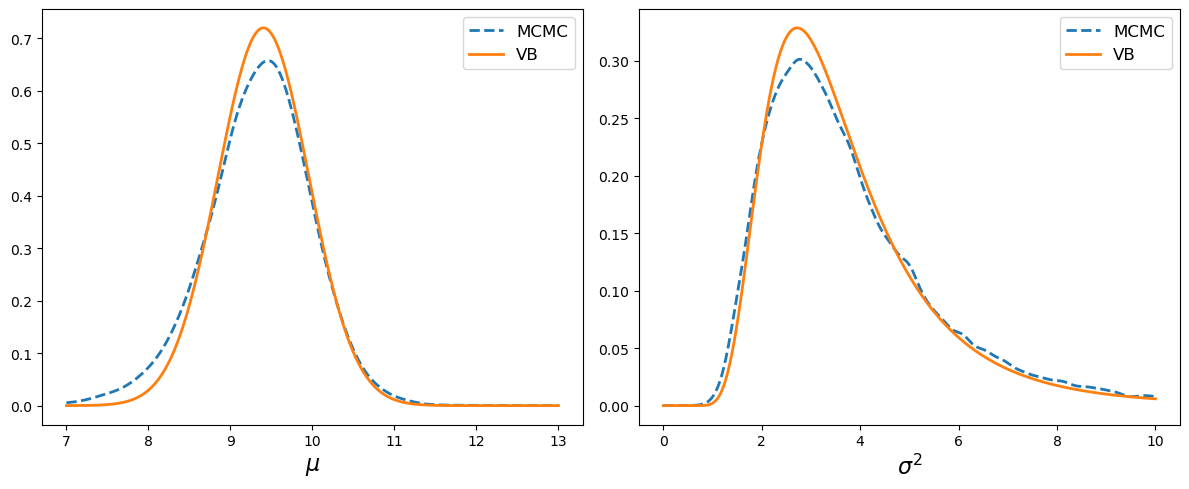

In [7]:

# ---------------------------------------------------------------------
# 2. Synthetic data
# ---------------------------------------------------------------------
y = np.array([11, 12, 8, 10, 9, 8, 9, 10, 13, 7], dtype=float)
n = len(y)

# hyperparameters
alpha0, beta0, mu0, sigma20 = 1.0, 1.0, 0.0, 10.0


# ---------------------------------------------------------------------
# 3. Execution + visualisation
# ---------------------------------------------------------------------
# --- Gibbs sampling (MCMC) ---
t0 = time.time()
mu_mcmc, sigma2_mcmc = gibbs_normal_model(y, alpha0, beta0, mu0, sigma20, 
                                          Nburn=10000, Niter=20000, seed=2020)
cpu_mcmc = time.time() - t0
print(f"CPU time MCMC: {cpu_mcmc:.4f} s")

# --- MFVB ---
t0 = time.time()
muq, sigma2q, alphaq, betaq, n_iter = mfvb_normal_model(y, alpha0, beta0, mu0, sigma20,
                                                        eps=1e-4)
cpu_vb = time.time() - t0
print(f"CPU time VB:   {cpu_vb:.4f} s  ({n_iter} CAVI iterations)")
print(f"VB estimates -> muq={muq:.4f}, sigma2q={sigma2q:.4f}, "
      f"alphaq={alphaq:.4f}, betaq={betaq:.4f}")

# --- Visualisation ---
fig = plot_mcmc_vs_vb(mu_mcmc, sigma2_mcmc, muq, sigma2q, alphaq, betaq,)
plt.show()

As shown in the figures, the estimated densities of $\mu$ and $\sigma^2$ based on the Gibbs sampler (MCMC) and Variational Bayes (MFVB) are quite similar. The VB approximation closely matches the MCMC posterior distributions for both parameters, with only minor discrepancies in the tails. This demonstrates that the mean-field variational approximation provides a computationally efficient alternative to MCMC for this normal model, achieving comparable accuracy while being significantly faster. 

Reference 

Tran, M.-N., Nguyen, T.-N., & Dao, V.-H. (2021). A practical tutorial on variational Bayes. *arXiv preprint arXiv:2103.01327*.

Blei, D. M., Kucukelbir, A., & McAuliffe, J. D. (2017). Variational inference: A review for statisticians. *Journal of the American Statistical Association*, 112(518), 859-877.